# 06 — Basis Modeling : Correction de la Non-Stationnarite

**Probleme** : Le modele souffre d'un biais systematique de +20-26 EUR (on-prediction) car il a appris le NIVEAU de prix de la crise 2022-2023.

**Solution** : Predire la BASE = `spot - merit_order_cost` au lieu du prix brut. La base est quasi-stationnaire.

**Plan** :
1. Etape 1 : Target swap only (raw basis)
2. Etape 2 : Basis + arcsinh
3. Etape 3 : Basis features (Cat 31)
4. Etape 4 : SHAP v4 re-ranking
5. Etape 5 : Sweep v3

In [1]:
import sys, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['font.size'] = 11

sys.path.insert(0, '..')
from src.data_loading import load_data, merge_train
from src.feature_engineering import build_features
from catboost import CatBoostRegressor, Pool
import yaml

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

x_train, y_train, x_test = load_data('../data/raw')
train = merge_train(x_train, y_train)
train_fe = build_features(train, config)

holdout_start = config['validation']['holdout_start']
mask_val = train_fe['datetime_CET'] >= holdout_start
df_train = train_fe[~mask_val].copy()
df_val = train_fe[mask_val].copy()

with open('../outputs/shap_ranking_v3_clean.json') as f:
    clean_ranking = json.load(f)

# CatBoost default params
CB_PARAMS = {
    'loss_function': 'RMSE', 'eval_metric': 'RMSE',
    'iterations': 5000, 'learning_rate': 0.03, 'depth': 8,
    'l2_leaf_reg': 5, 'subsample': 0.8, 'random_seed': 42,
    'verbose': 0, 'allow_writing_files': False, 'use_best_model': True,
}

print(f'Train: {df_train.shape}, Val: {df_val.shape}')

Train: (13921, 450), Val: (3623, 450)


## 0. Explorons la base (spot - merit_order_cost)

Avant de modéliser, regardons les proprietes statistiques de la base.

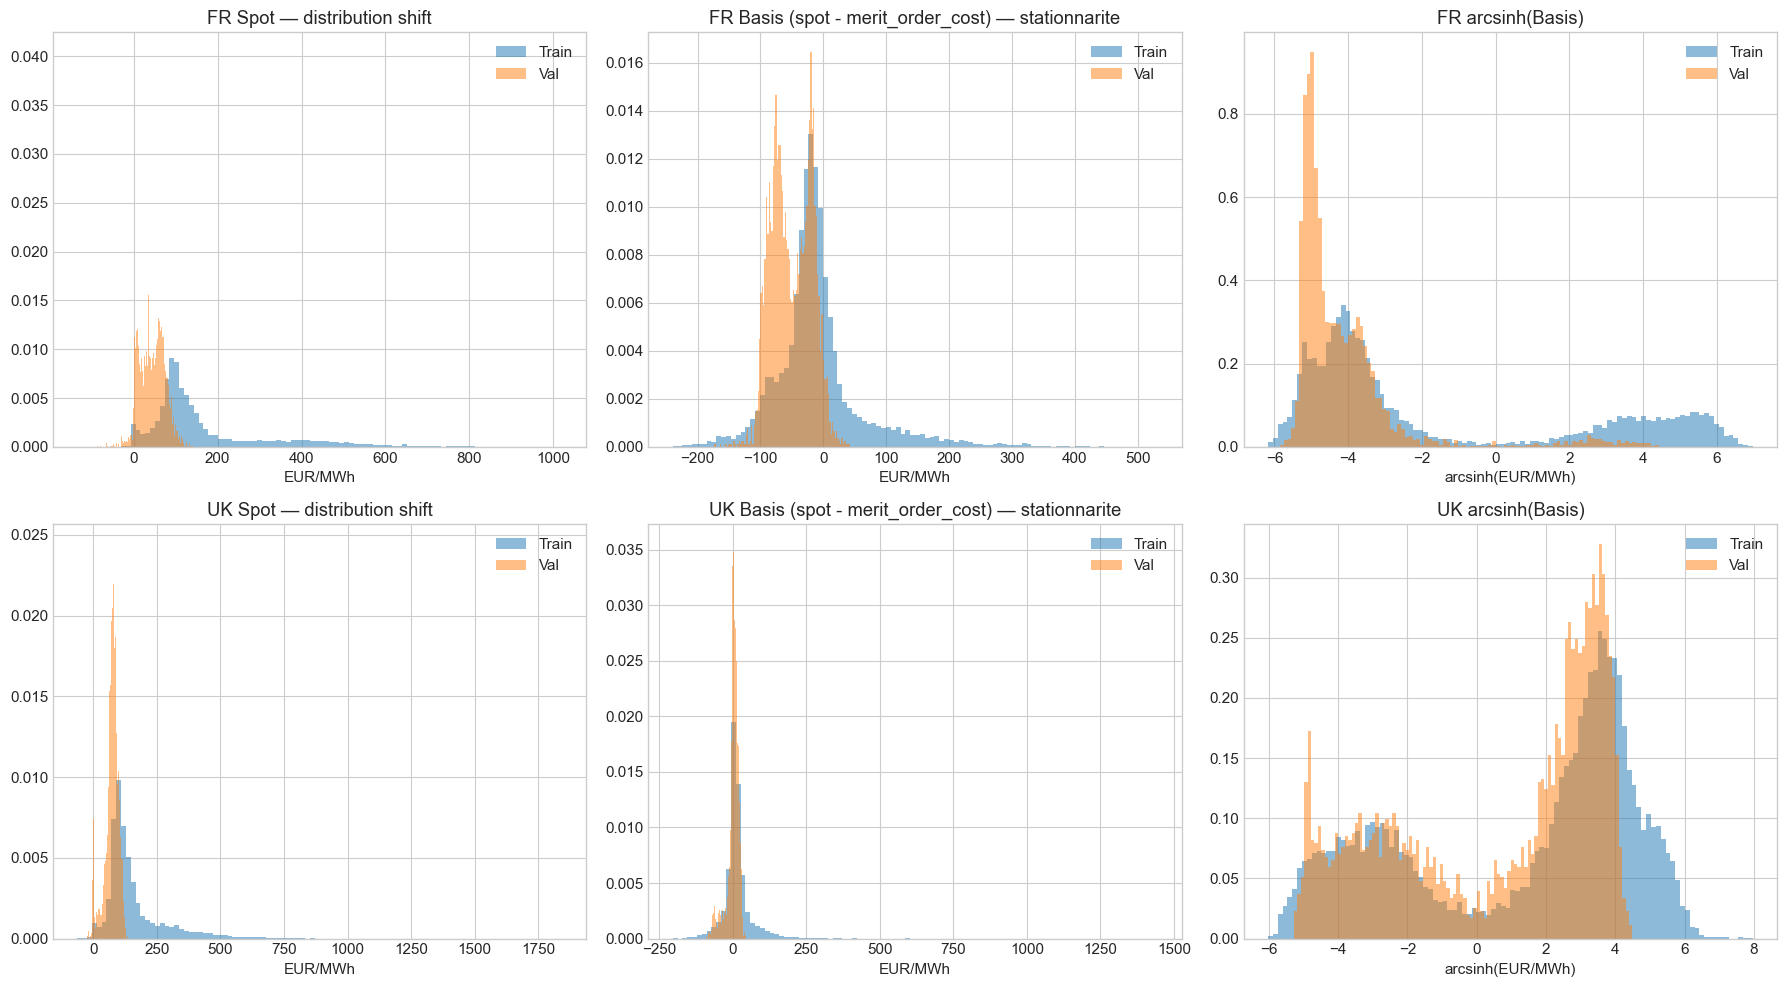


=== FR ===
  Spot  — Train: mean=167.2, std=147.3
          Val:   mean=40.2, std=31.0
          SHIFT: -127.0 EUR
  Basis — Train: mean=-9.7, std=72.7
          Val:   mean=-50.5, std=31.8
          SHIFT: -40.8 EUR

=== UK ===
  Spot  — Train: mean=158.1, std=120.5
          Val:   mean=74.6, std=25.8
          SHIFT: -83.4 EUR
  Basis — Train: mean=13.4, std=52.2
          Val:   mean=-0.3, std=21.5
          SHIFT: -13.6 EUR


In [2]:
# Compute basis for both targets
for prefix in ['fr', 'uk']:
    train_fe[f'{prefix}_basis'] = train_fe[f'{prefix}_spot'] - train_fe[f'{prefix}_merit_order_cost']
    df_train[f'{prefix}_basis'] = df_train[f'{prefix}_spot'] - df_train[f'{prefix}_merit_order_cost']
    df_val[f'{prefix}_basis'] = df_val[f'{prefix}_spot'] - df_val[f'{prefix}_merit_order_cost']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, prefix in enumerate(['fr', 'uk']):
    label = 'FR' if prefix == 'fr' else 'UK'
    
    # Distribution spot vs basis
    axes[i, 0].hist(df_train[f'{prefix}_spot'], bins=100, alpha=0.5, label='Train', density=True)
    axes[i, 0].hist(df_val[f'{prefix}_spot'], bins=100, alpha=0.5, label='Val', density=True)
    axes[i, 0].set_title(f'{label} Spot — distribution shift')
    axes[i, 0].set_xlabel('EUR/MWh')
    axes[i, 0].legend()
    
    axes[i, 1].hist(df_train[f'{prefix}_basis'], bins=100, alpha=0.5, label='Train', density=True)
    axes[i, 1].hist(df_val[f'{prefix}_basis'], bins=100, alpha=0.5, label='Val', density=True)
    axes[i, 1].set_title(f'{label} Basis (spot - merit_order_cost) — stationnarite')
    axes[i, 1].set_xlabel('EUR/MWh')
    axes[i, 1].legend()
    
    axes[i, 2].hist(np.arcsinh(df_train[f'{prefix}_basis']), bins=100, alpha=0.5, label='Train', density=True)
    axes[i, 2].hist(np.arcsinh(df_val[f'{prefix}_basis']), bins=100, alpha=0.5, label='Val', density=True)
    axes[i, 2].set_title(f'{label} arcsinh(Basis)')
    axes[i, 2].set_xlabel('arcsinh(EUR/MWh)')
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

# Stats
for prefix, label in [('fr', 'FR'), ('uk', 'UK')]:
    print(f'\n=== {label} ===')
    print(f'  Spot  — Train: mean={df_train[f"{prefix}_spot"].mean():.1f}, std={df_train[f"{prefix}_spot"].std():.1f}')
    print(f'          Val:   mean={df_val[f"{prefix}_spot"].mean():.1f}, std={df_val[f"{prefix}_spot"].std():.1f}')
    print(f'          SHIFT: {df_val[f"{prefix}_spot"].mean() - df_train[f"{prefix}_spot"].mean():+.1f} EUR')
    print(f'  Basis — Train: mean={df_train[f"{prefix}_basis"].mean():.1f}, std={df_train[f"{prefix}_basis"].std():.1f}')
    print(f'          Val:   mean={df_val[f"{prefix}_basis"].mean():.1f}, std={df_val[f"{prefix}_basis"].std():.1f}')
    print(f'          SHIFT: {df_val[f"{prefix}_basis"].mean() - df_train[f"{prefix}_basis"].mean():+.1f} EUR')

## Baseline Basis (target swap only)

On garde les memes features, on change juste le target:
- `y = spot` → `y = spot - merit_order_cost`
- A la prediction: `spot_pred = merit_order_cost + model.predict(X)`

In [3]:
def train_and_eval(X_tr, y_tr, X_va, y_va, merit_cost_va, transform='raw', label=''):
    """Train CatBoost and return RMSE on original spot scale.
    
    transform: 'raw' | 'arcsinh'
    y_tr/y_va can be raw spot, basis, etc.
    merit_cost_va: merit_order_cost values on val set (None if target is raw spot)
    """
    if transform == 'arcsinh':
        y_tr_t = np.arcsinh(y_tr)
        y_va_t = np.arcsinh(y_va)
    else:
        y_tr_t = y_tr
        y_va_t = y_va
    
    model = CatBoostRegressor(**CB_PARAMS)
    model.fit(Pool(X_tr, y_tr_t), eval_set=Pool(X_va, y_va_t),
              early_stopping_rounds=100, verbose=0)
    
    preds_t = model.predict(X_va)
    
    if transform == 'arcsinh':
        preds = np.sinh(preds_t)
    else:
        preds = preds_t
    
    # Convert back to spot scale if basis target
    if merit_cost_va is not None:
        preds_spot = merit_cost_va + preds
    else:
        preds_spot = preds
    
    best_iter = model.get_best_iteration()
    return preds_spot, best_iter, model


results = {}

for target_name, n_features in [('fr_spot', 20), ('uk_spot', 75)]:
    prefix = target_name.split('_')[0]
    features = [f for f in clean_ranking[target_name][:n_features] if f in df_train.columns]
    
    X_tr = df_train[features]
    X_va = df_val[features]
    y_tr_spot = df_train[target_name]
    y_va_spot = df_val[target_name]
    y_tr_basis = df_train[f'{prefix}_basis']
    y_va_basis = df_val[f'{prefix}_basis']
    merit_va = df_val[f'{prefix}_merit_order_cost'].values
    
    print(f'\n{"=" * 60}')
    print(f'  {target_name.upper()} — {len(features)} features')
    print(f'{"=" * 60}')
    
    # A: Raw spot target
    preds_A, iters_A, _ = train_and_eval(X_tr, y_tr_spot, X_va, y_va_spot, None, 'raw')
    rmse_A = np.sqrt(np.mean((y_va_spot.values - preds_A) ** 2))
    
    # B: arcsinh(spot) target
    preds_B, iters_B, _ = train_and_eval(X_tr, y_tr_spot, X_va, y_va_spot, None, 'arcsinh')
    rmse_B = np.sqrt(np.mean((y_va_spot.values - preds_B) ** 2))
    
    # C: Basis target (raw)
    preds_C, iters_C, _ = train_and_eval(X_tr, y_tr_basis, X_va, y_va_basis, merit_va, 'raw')
    rmse_C = np.sqrt(np.mean((y_va_spot.values - preds_C) ** 2))
    
    # D: Basis + arcsinh
    preds_D, iters_D, _ = train_and_eval(X_tr, y_tr_basis, X_va, y_va_basis, merit_va, 'arcsinh')
    rmse_D = np.sqrt(np.mean((y_va_spot.values - preds_D) ** 2))
    
    results[target_name] = {
        'A_raw_spot': rmse_A, 'B_arcsinh_spot': rmse_B,
        'C_raw_basis': rmse_C, 'D_arcsinh_basis': rmse_D,
        'iters': {'A': iters_A, 'B': iters_B, 'C': iters_C, 'D': iters_D},
        'preds': {'A': preds_A, 'B': preds_B, 'C': preds_C, 'D': preds_D},
    }
    
    print(f'  A) Raw spot target:      RMSE = {rmse_A:.3f}  ({iters_A} iters)')
    print(f'  B) arcsinh(spot) target:  RMSE = {rmse_B:.3f}  ({iters_B} iters)')
    print(f'  C) Raw basis target:      RMSE = {rmse_C:.3f}  ({iters_C} iters)')
    print(f'  D) arcsinh(basis) target: RMSE = {rmse_D:.3f}  ({iters_D} iters)')
    
    best = min(rmse_A, rmse_B, rmse_C, rmse_D)
    best_label = {rmse_A: 'A', rmse_B: 'B', rmse_C: 'C', rmse_D: 'D'}[best]
    print(f'\n  >>> BEST: {best_label} = {best:.3f} EUR')


  FR_SPOT — 20 features


  A) Raw spot target:      RMSE = 27.520  (1271 iters)
  B) arcsinh(spot) target:  RMSE = 26.097  (537 iters)
  C) Raw basis target:      RMSE = 27.630  (1356 iters)
  D) arcsinh(basis) target: RMSE = 33.318  (291 iters)

  >>> BEST: B = 26.097 EUR

  UK_SPOT — 75 features


  A) Raw spot target:      RMSE = 10.445  (1046 iters)
  B) arcsinh(spot) target:  RMSE = 10.747  (667 iters)
  C) Raw basis target:      RMSE = 9.866  (1255 iters)
  D) arcsinh(basis) target: RMSE = 13.540  (1036 iters)

  >>> BEST: C = 9.866 EUR


In [4]:
# Summary table
print('\n' + '=' * 70)
print('  RESUME — A/B Test Target Transformation')
print('=' * 70)
print(f'{"Methode":30s} {"FR RMSE":>10s} {"UK RMSE":>10s} {"Combined":>10s}')
print('-' * 70)

for key, label in [('A_raw_spot', 'A) Raw spot'),
                    ('B_arcsinh_spot', 'B) arcsinh(spot)'),
                    ('C_raw_basis', 'C) Raw basis'),
                    ('D_arcsinh_basis', 'D) arcsinh(basis)')]:
    fr = results['fr_spot'][key]
    uk = results['uk_spot'][key]
    combined = (fr + uk) / 2
    print(f'{label:30s} {fr:10.3f} {uk:10.3f} {combined:10.3f}')

print('-' * 70)
# Best combo: pick best per target
fr_best_key = min(['A_raw_spot', 'B_arcsinh_spot', 'C_raw_basis', 'D_arcsinh_basis'],
                  key=lambda k: results['fr_spot'][k])
uk_best_key = min(['A_raw_spot', 'B_arcsinh_spot', 'C_raw_basis', 'D_arcsinh_basis'],
                  key=lambda k: results['uk_spot'][k])
fr_best = results['fr_spot'][fr_best_key]
uk_best = results['uk_spot'][uk_best_key]
print(f'{"Best per-target combo":30s} {fr_best:10.3f} {uk_best:10.3f} {(fr_best + uk_best)/2:10.3f}')
print(f'  FR best: {fr_best_key}')
print(f'  UK best: {uk_best_key}')


  RESUME — A/B Test Target Transformation
Methode                           FR RMSE    UK RMSE   Combined
----------------------------------------------------------------------
A) Raw spot                        27.520     10.445     18.982
B) arcsinh(spot)                   26.097     10.747     18.422
C) Raw basis                       27.630      9.866     18.748
D) arcsinh(basis)                  33.318     13.540     23.429
----------------------------------------------------------------------
Best per-target combo              26.097      9.866     17.982
  FR best: B_arcsinh_spot
  UK best: C_raw_basis


## Etape 1b — Analyse du biais : le basis a-t-il corrige la on-prediction ?

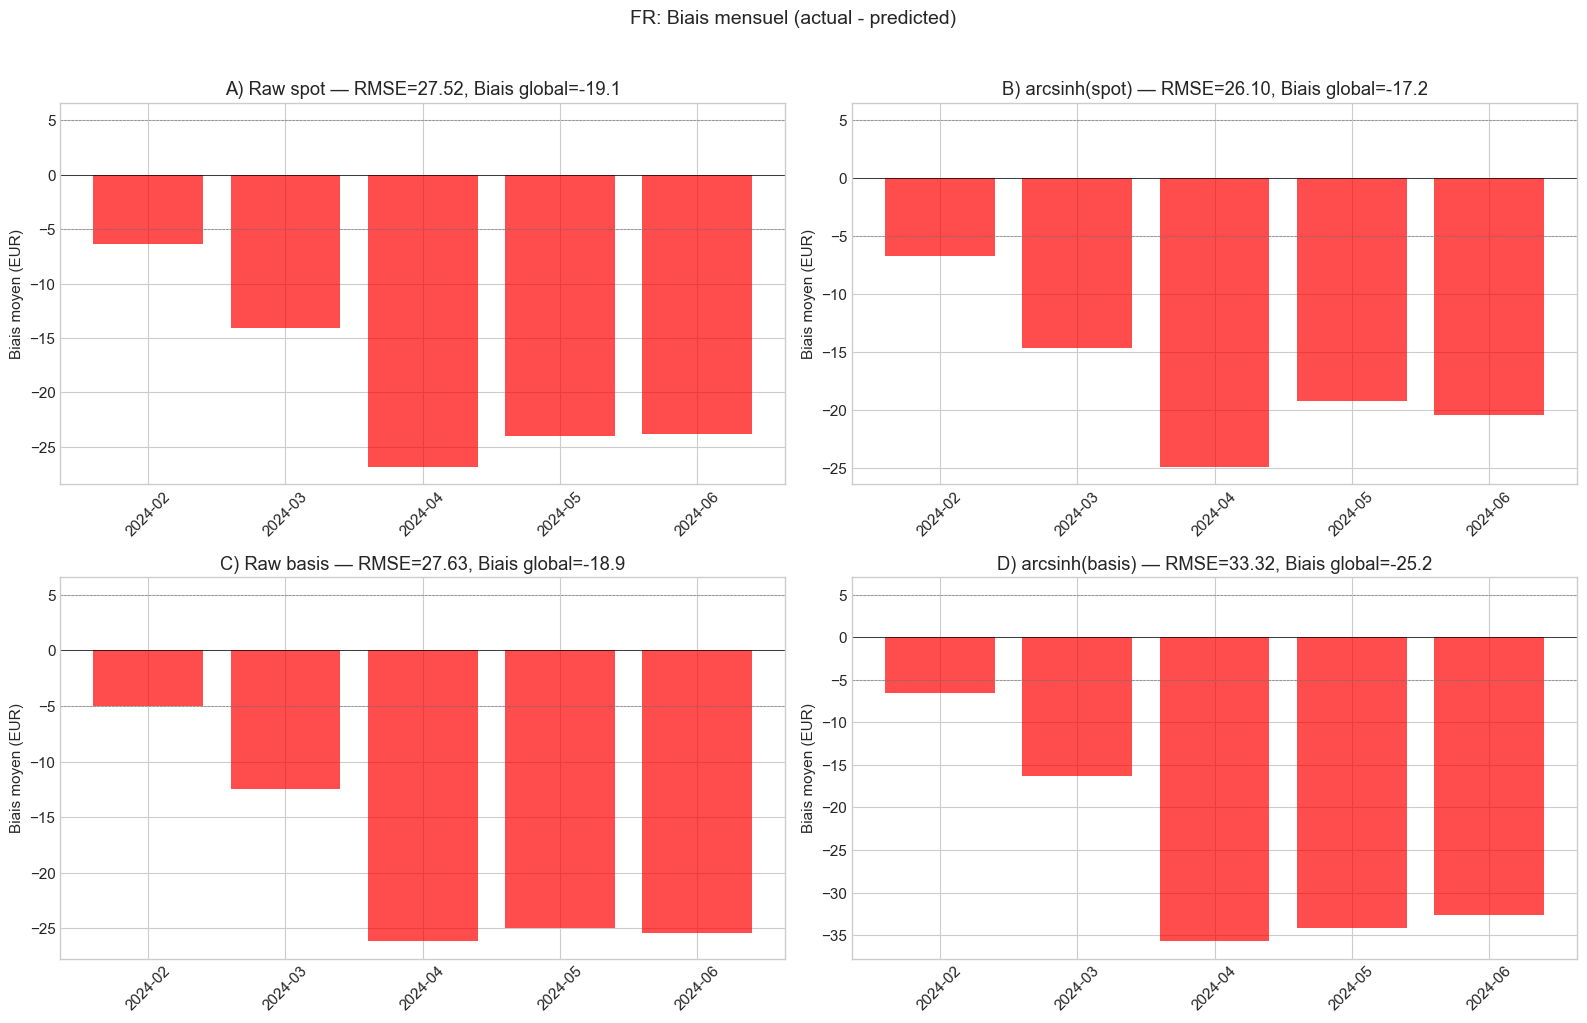

In [5]:
# Focus on FR: compare bias before/after basis modeling
y_actual = df_val['fr_spot'].values
dt = pd.to_datetime(df_val['datetime_CET'])
months = dt.dt.to_period('M')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (key, label) in enumerate([('A_raw_spot', 'A) Raw spot'),
                                     ('B_arcsinh_spot', 'B) arcsinh(spot)'),
                                     ('C_raw_basis', 'C) Raw basis'),
                                     ('D_arcsinh_basis', 'D) arcsinh(basis)')]):
    ax = axes[idx // 2, idx % 2]
    preds = results['fr_spot']['preds'][key[0]]
    errors = y_actual - preds
    
    # Monthly bias
    bias_monthly = pd.Series(errors, index=df_val.index).groupby(months).mean()
    rmse_monthly = pd.Series(errors**2, index=df_val.index).groupby(months).apply(lambda x: np.sqrt(x.mean()))
    
    x_pos = range(len(bias_monthly))
    ax.bar(x_pos, bias_monthly.values, alpha=0.7, color=['green' if b > -5 and b < 5 else 'red' for b in bias_monthly.values])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axhline(5, color='gray', linewidth=0.5, linestyle='--')
    ax.axhline(-5, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(m) for m in bias_monthly.index], rotation=45)
    ax.set_ylabel('Biais moyen (EUR)')
    rmse = results['fr_spot'][key]
    global_bias = errors.mean()
    ax.set_title(f'{label} — RMSE={rmse:.2f}, Biais global={global_bias:+.1f}')

plt.suptitle('FR: Biais mensuel (actual - predicted)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Detailed bias table for FR
print('FR — Biais par mois (actual - predicted):')

bias_df = pd.DataFrame(index=sorted(months.unique()))
for key_letter, key in [('A', 'A_raw_spot'), ('B', 'B_arcsinh_spot'),
                         ('C', 'C_raw_basis'), ('D', 'D_arcsinh_basis')]:
    preds = results['fr_spot']['preds'][key_letter]
    errors = pd.Series(y_actual - preds, index=df_val.index)
    bias_df[key_letter] = errors.groupby(months).mean()

print(bias_df.round(1).to_string())
print()
print('Global bias:')
for col in bias_df.columns:
    print(f'  {col}: {bias_df[col].mean():+.1f} EUR')

FR — Biais par mois (actual - predicted):
            A     B     C     D
2024-02  -6.4  -6.7  -5.0  -6.6
2024-03 -14.1 -14.6 -12.5 -16.3
2024-04 -26.8 -24.9 -26.2 -35.7
2024-05 -24.0 -19.2 -25.0 -34.2
2024-06 -23.8 -20.4 -25.4 -32.6

Global bias:
  A: -19.0 EUR
  B: -17.1 EUR
  C: -18.8 EUR
  D: -25.1 EUR


## Etape 1c — UK : meme analyse

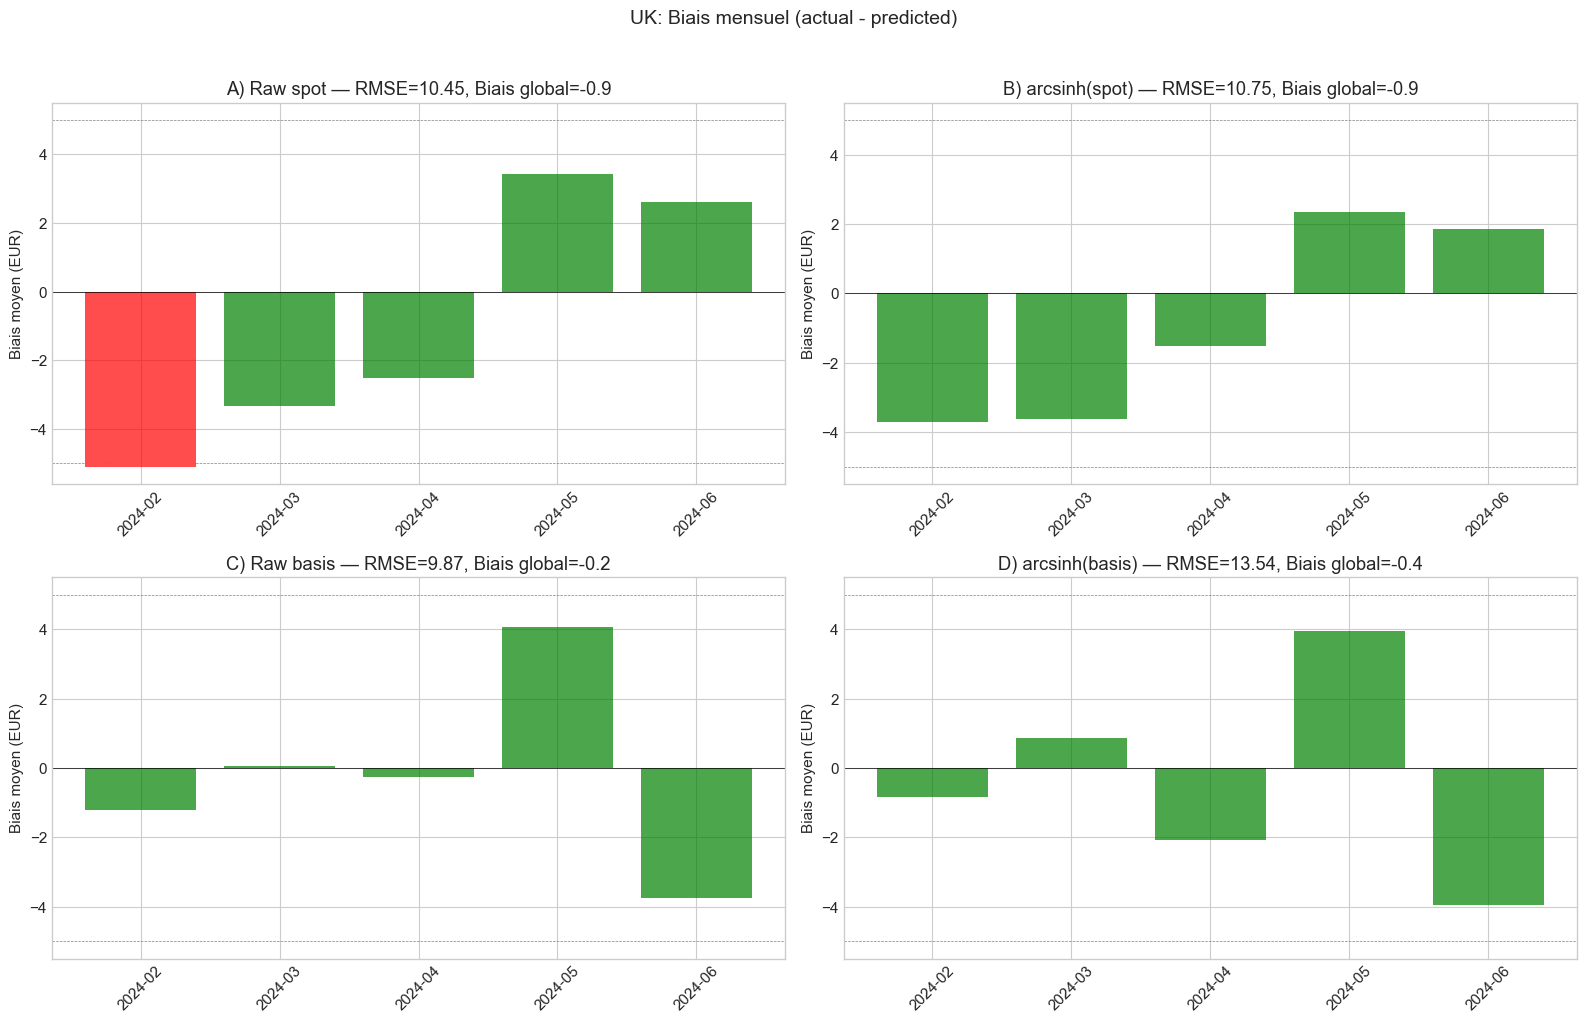

UK — Biais par mois:
           A    B    C    D
2024-02 -5.1 -3.7 -1.2 -0.8
2024-03 -3.3 -3.6  0.1  0.9
2024-04 -2.5 -1.5 -0.3 -2.1
2024-05  3.4  2.3  4.1  3.9
2024-06  2.6  1.9 -3.7 -3.9


In [7]:
# UK bias analysis
y_actual_uk = df_val['uk_spot'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (key, label) in enumerate([('A_raw_spot', 'A) Raw spot'),
                                     ('B_arcsinh_spot', 'B) arcsinh(spot)'),
                                     ('C_raw_basis', 'C) Raw basis'),
                                     ('D_arcsinh_basis', 'D) arcsinh(basis)')]):
    ax = axes[idx // 2, idx % 2]
    preds = results['uk_spot']['preds'][key[0]]
    errors = y_actual_uk - preds
    
    bias_monthly = pd.Series(errors, index=df_val.index).groupby(months).mean()
    
    x_pos = range(len(bias_monthly))
    ax.bar(x_pos, bias_monthly.values, alpha=0.7,
           color=['green' if -5 < b < 5 else 'red' for b in bias_monthly.values])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axhline(5, color='gray', linewidth=0.5, linestyle='--')
    ax.axhline(-5, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(m) for m in bias_monthly.index], rotation=45)
    ax.set_ylabel('Biais moyen (EUR)')
    rmse = results['uk_spot'][key]
    global_bias = errors.mean()
    ax.set_title(f'{label} — RMSE={rmse:.2f}, Biais global={global_bias:+.1f}')

plt.suptitle('UK: Biais mensuel (actual - predicted)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# UK bias table
bias_df_uk = pd.DataFrame(index=sorted(months.unique()))
for key_letter, key in [('A', 'A_raw_spot'), ('B', 'B_arcsinh_spot'),
                         ('C', 'C_raw_basis'), ('D', 'D_arcsinh_basis')]:
    preds = results['uk_spot']['preds'][key_letter]
    errors = pd.Series(y_actual_uk - preds, index=df_val.index)
    bias_df_uk[key_letter] = errors.groupby(months).mean()

print('UK — Biais par mois:')
print(bias_df_uk.round(1).to_string())

## Feature count sweep with basis

Le nombre optimal de features change-t-il with basis target ?

In [8]:
feature_counts = [20, 30, 50, 75, 100, 150, 200]
sweep_results = {}

for target_name in ['fr_spot', 'uk_spot']:
    prefix = target_name.split('_')[0]
    sweep_results[target_name] = {}
    
    y_tr_basis = df_train[f'{prefix}_basis']
    y_va_basis = df_val[f'{prefix}_basis']
    y_va_spot = df_val[target_name]
    merit_va = df_val[f'{prefix}_merit_order_cost'].values
    
    # Determine best transform from Step 1
    # Try both raw basis and arcsinh basis
    for transform in ['raw', 'arcsinh']:
        tag = f'basis_{transform}'
        sweep_results[target_name][tag] = {}
        
        for n_feat in feature_counts:
            features = [f for f in clean_ranking[target_name][:n_feat] if f in df_train.columns]
            if len(features) < 5:
                continue
            
            X_tr = df_train[features]
            X_va = df_val[features]
            
            preds_spot, iters, _ = train_and_eval(
                X_tr, y_tr_basis, X_va, y_va_basis, merit_va, transform
            )
            rmse = np.sqrt(np.mean((y_va_spot.values - preds_spot) ** 2))
            sweep_results[target_name][tag][n_feat] = rmse
            print(f'  {target_name} | {tag} | {n_feat:>3d} feat | RMSE = {rmse:.3f} ({iters} iters)')
    
    print()

  fr_spot | basis_raw |  20 feat | RMSE = 27.630 (1356 iters)


  fr_spot | basis_raw |  30 feat | RMSE = 28.727 (725 iters)


  fr_spot | basis_raw |  50 feat | RMSE = 33.835 (107 iters)


  fr_spot | basis_raw |  75 feat | RMSE = 28.837 (119 iters)


  fr_spot | basis_raw | 100 feat | RMSE = 29.765 (87 iters)


...

  uk_spot | basis_arcsinh |  50 feat | RMSE = 13.416 (468 iters)


  uk_spot | basis_arcsinh |  75 feat | RMSE = 13.540 (1036 iters)


  uk_spot | basis_arcsinh | 100 feat | RMSE = 14.201 (691 iters)


  uk_spot | basis_arcsinh | 150 feat | RMSE = 13.978 (1261 iters)


  uk_spot | basis_arcsinh | 200 feat | RMSE = 13.961 (1104 iters)



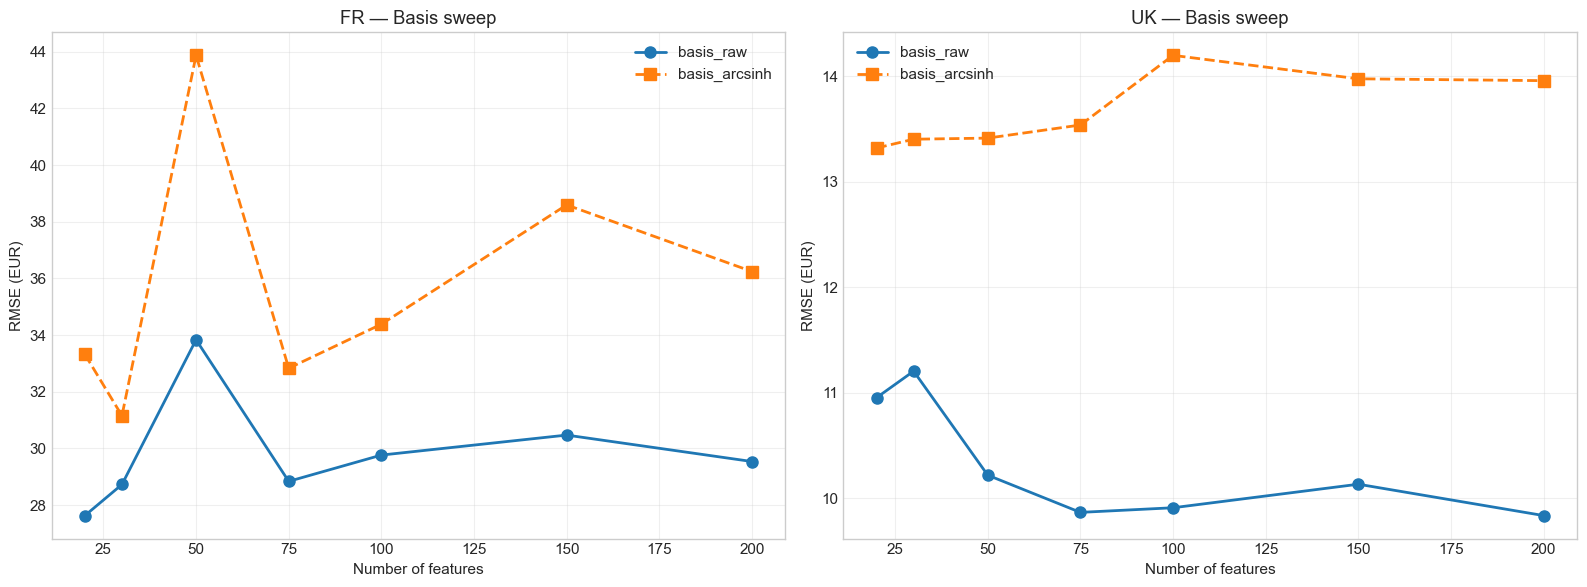


Best configurations:
  fr_spot | basis_raw: 20 features -> RMSE = 27.630
  fr_spot | basis_arcsinh: 30 features -> RMSE = 31.154
  uk_spot | basis_raw: 200 features -> RMSE = 9.836
  uk_spot | basis_arcsinh: 20 features -> RMSE = 13.322


In [9]:
# Plot sweep results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, target_name in enumerate(['fr_spot', 'uk_spot']):
    ax = axes[idx]
    label = 'FR' if 'fr' in target_name else 'UK'
    
    for tag, style in [('basis_raw', 'o-'), ('basis_arcsinh', 's--')]:
        data = sweep_results[target_name][tag]
        if data:
            x = sorted(data.keys())
            y = [data[k] for k in x]
            ax.plot(x, y, style, label=tag, linewidth=2, markersize=8)
    
    ax.set_xlabel('Number of features')
    ax.set_ylabel('RMSE (EUR)')
    ax.set_title(f'{label} — Basis sweep')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best configs
print('\nBest configurations:')
for target_name in ['fr_spot', 'uk_spot']:
    for tag in ['basis_raw', 'basis_arcsinh']:
        data = sweep_results[target_name][tag]
        if data:
            best_n = min(data, key=data.get)
            print(f'  {target_name} | {tag}: {best_n} features -> RMSE = {data[best_n]:.3f}')

## Etape 2b — Comparaison globale : ancien vs nouveau

In [10]:
print('=' * 70)
print('  COMPARAISON GLOBALE')
print('=' * 70)
print(f'{"Config":40s} {"FR":>8s} {"UK":>8s} {"Combined":>10s}')
print('-' * 70)

# Previous best
print(f'{"v2: raw spot, 20/75 feat":40s} {results["fr_spot"]["A_raw_spot"]:8.3f} {results["uk_spot"]["A_raw_spot"]:8.3f} {(results["fr_spot"]["A_raw_spot"] + results["uk_spot"]["A_raw_spot"])/2:10.3f}')
print(f'{"v2: arcsinh(spot), 20/75 feat":40s} {results["fr_spot"]["B_arcsinh_spot"]:8.3f} {results["uk_spot"]["B_arcsinh_spot"]:8.3f} {(results["fr_spot"]["B_arcsinh_spot"] + results["uk_spot"]["B_arcsinh_spot"])/2:10.3f}')

# Basis with 20/75
print(f'{"v3: basis, 20/75 feat":40s} {results["fr_spot"]["C_raw_basis"]:8.3f} {results["uk_spot"]["C_raw_basis"]:8.3f} {(results["fr_spot"]["C_raw_basis"] + results["uk_spot"]["C_raw_basis"])/2:10.3f}')
print(f'{"v3: arcsinh(basis), 20/75 feat":40s} {results["fr_spot"]["D_arcsinh_basis"]:8.3f} {results["uk_spot"]["D_arcsinh_basis"]:8.3f} {(results["fr_spot"]["D_arcsinh_basis"] + results["uk_spot"]["D_arcsinh_basis"])/2:10.3f}')

# Best from sweep
print('-' * 70)
for tag in ['basis_raw', 'basis_arcsinh']:
    fr_data = sweep_results['fr_spot'][tag]
    uk_data = sweep_results['uk_spot'][tag]
    if fr_data and uk_data:
        fr_best_n = min(fr_data, key=fr_data.get)
        uk_best_n = min(uk_data, key=uk_data.get)
        fr_rmse = fr_data[fr_best_n]
        uk_rmse = uk_data[uk_best_n]
        combined = (fr_rmse + uk_rmse) / 2
        print(f'{f"SWEEP {tag} ({fr_best_n}/{uk_best_n} feat)":40s} {fr_rmse:8.3f} {uk_rmse:8.3f} {combined:10.3f}')

  COMPARAISON GLOBALE
Config                                         FR       UK   Combined
----------------------------------------------------------------------
v2: raw spot, 20/75 feat                   27.520   10.445     18.982
v2: arcsinh(spot), 20/75 feat              26.097   10.747     18.422
v3: basis, 20/75 feat                      27.630    9.866     18.748
v3: arcsinh(basis), 20/75 feat             33.318   13.540     23.429
----------------------------------------------------------------------
SWEEP basis_raw (20/200 feat)              27.630    9.836     18.733
SWEEP basis_arcsinh (30/20 feat)           31.154   13.322     22.238


In [11]:
# Save results
import json

save_data = {
    'step1_fixed_features': {
        target: {k: v for k, v in res_dict.items() if k != 'preds' and k != 'iters'}
        for target, res_dict in results.items()
    },
    'step1_iterations': {
        target: res_dict.get('iters', {})
        for target, res_dict in results.items()
    },
    'step2_sweep': {
        target: {tag: {str(k): v for k, v in d.items()}
                 for tag, d in tag_dict.items()}
        for target, tag_dict in sweep_results.items()
    },
}

with open('../outputs/basis_modeling_results.json', 'w') as f:
    json.dump(save_data, f, indent=2)

print('Results saved to outputs/basis_modeling_results.json')

Results saved to outputs/basis_modeling_results.json
